<a href="https://colab.research.google.com/github/2873991-Manthena/Dissertation/blob/main/DISSERTATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

This section imports all the required Python libraries for data manipulation, visualization, exploratory data analysis, and natural language processing. These libraries will be used throughout the project for preprocessing, feature extraction, and model development.

In [ ]:
# ==============================================================
# 1. IMPORT REQUIRED LIBRARIES
# ==============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text Processing
import re
import string
from collections import Counter

# NLP
import nltk

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Mount Google Drive

Google Drive is mounted to enable easy access to the datasets and to save the processed files for future stages of the project.

In [ ]:
# ==============================================================
# 2. MOUNT GOOGLE DRIVE
# ==============================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 3. Load Datasets

Two publicly available MBTI datasets are loaded into the notebook. Both datasets contain textual posts along with their corresponding MBTI personality labels. These datasets will be explored and preprocessed before training the prediction models.

In [ ]:
# ==============================================================
# 3. LOAD DATASETS
# ==============================================================

# Dataset 1
mbti1 = pd.read_csv("/content/drive/MyDrive/Dissertation/Datasets/mbti_1.csv")
# Dataset 2
mbti500 = pd.read_csv("/content/drive/MyDrive/Dissertation/Datasets/MBTI 500.csv")

In [ ]:
print("="*70)
print("MBTI DATASET 1")
print("="*70)

display(mbti1.head())

print("="*70)
print("MBTI DATASET 2")
print("="*70)

display(mbti500.head())

MBTI DATASET 1


type  \
0  INFJ   
1  ENTP   
2  INTP   
3  INTJ   
4  ENTJ   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

MBTI DATASET 2


,posts,type
0,know intj tool use interaction people excuse antisocial truly enlighten mastermind know would count pet peeze something time matter people either whether group people mall never see best friend sit outside conversation jsut listen want interject sit formulate say wait inject argument thought find fascinate sit watch people talk people fascinate sit class watch different people find intrigue dad intj u stand look like line safeway watch people home talk people like think military job people voluntarily go job important show deference endanger live glorify way civilian think pretty ignorant general think military necessary defense mechanism political tactic feel like u specifically invest much money could put money education whatnot though personally sound budget aernative really comment one way base two politician eye year ago come name somewhat important kinda role model nowadays pick keep score individual level mean little vary accord number condition day may score high others low sweat really good cast physiotherapist like fiberglass cast break arm whatever sometimes want take picture beast put someone arm sadly people blind brilliance need tell directly wave arm frantically totally beyond oblivious get good eye contact help lot start find like attention get opposite sex notice however gay men tend little aggressive always walk away flatter like alcohol bad start generally keep go pas run money even mention fact crave cocaine drink political power mainly desire form power okay status still never study day life never learn study feel like real whatever reason college prepare recieve people like depend career introductory course help start rid bike write essay etc choose career least stimulate mind expand perspective reality without college like kiss sound ear yup roll end quite strange confession time mind wish people le judgemental self perceive flaw run situation person confess something expect judge one way another freak realize judge gasp human interpret acknowledgement sign terrible person agree bad impulse ditch safe place quickly become somewhere dump emotional trash gui free interest play role mind noise midnight still go make really cranky lol already know autistic even know asd associate intj people mind two even remotely similar card conspiracy hallmark post office long enough people whether individual people government conglomerate corporation understand biodiversity something need fund even though make money instead insurance policy fine aka negative external form cost need separate positive surplus cost much thing like seed bank visualize cost percent farm benefit cost yet need fund separately individual farmer individual farmer corporation think well someone else people free rider problem seed bank never get set stuff like government capitalism may provide innovation government set regulation prevent negative consequence unintentional externality seed bank get set half thousand differents solution perhaps general tax commerce usage fee similar california recycle fee electronics form donation pledge system regardless need get seed bank get expert truely know enough need biodiversity seed farm whether enough seed farm different location properly fund amp bsp say expert know enough due single college class involve economics say economic class involve lot history use case study green revolution,INTJ
1,rap music ehh opp yeah know valid well know fact people like socialize party even personality let alone personality type reason remain mystery likely function stack see party goer barely function function stack well fact even get two together nigh impossible lead entire personality consist shadow function though theorize widely dismiss though may help explain inherent love night life like something stop apply eliminate genuine character flaw quickly notice rationalisation vote trump basically hillary attractive candidate lacklustre corrupt beg question president racist sexist bad really care le either wa

## 4. Basic Information

The structure of each dataset is examined to understand the number of records, available features, data types, and memory requirements. This provides an overview of the datasets before preprocessing begins.

In [ ]:
# ==============================================================
# 4. BASIC INFORMATION
# ==============================================================

def dataset_info(df, name):

    print("="*70)
    print(name)
    print("="*70)

    print("\nShape")
    print(df.shape)

    print("\nColumns")
    print(df.columns.tolist())

    print("\nData Types")
    print(df.dtypes)

    print("\nMemory Usage")
    print(df.memory_usage(deep=True))

    print("\nTotal Memory Used")
    print(round(df.memory_usage(deep=True).sum()/1024**2,2),"MB")

In [ ]:
dataset_info(mbti1,"MBTI DATASET 1")

MBTI DATASET 1

Shape
(8675, 2)

Columns
['type', 'posts']

Data Types
type     object
posts    object
dtype: object

Memory Usage
Index         132
type       459775
posts    72862257
dtype: int64

Total Memory Used
69.93 MB


In [ ]:
dataset_info(mbti500,"MBTI DATASET 2")

MBTI DATASET 2

Shape
(106067, 2)

Columns
['posts', 'type']

Data Types
posts    object
type     object
dtype: object

Memory Usage
Index          132
posts    360203077
type       5621551
dtype: int64

Total Memory Used
348.88 MB


## 5. Missing Value Analysis

Missing values are identified to determine whether incomplete records exist within the datasets. Understanding missing data is essential before performing any preprocessing or model development.

In [ ]:
# ==============================================================
# 5. MISSING VALUE ANALYSIS
# ==============================================================

def missing_values(df,name):

    missing=df.isnull().sum()

    percentage=(missing/len(df))*100

    result=pd.DataFrame({

        "Missing Values":missing,

        "Percentage":percentage

    })

    print("="*70)
    print(name)
    print("="*70)

    display(result)

In [ ]:
missing_values(mbti1,"MBTI Dataset 1")

MBTI Dataset 1


,Missing Values,Percentage
type,0,0.0
posts,0,0.0


In [ ]:
missing_values(mbti500,"MBTI Dataset 2")

MBTI Dataset 2


,Missing Values,Percentage
posts,0,0.0
type,0,0.0


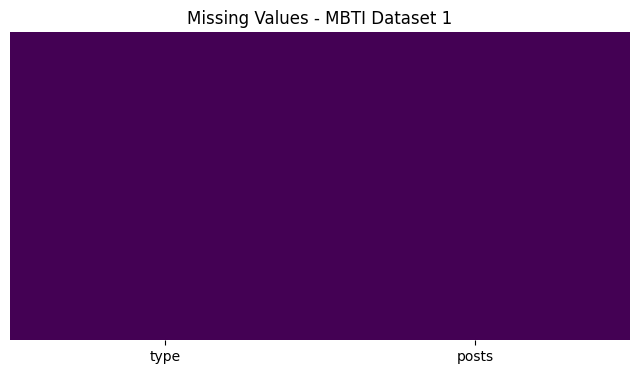

In [ ]:
plt.figure(figsize=(8,4))

sns.heatmap(mbti1.isnull(),
            cbar=False,
            yticklabels=False,
            cmap="viridis")

plt.title("Missing Values - MBTI Dataset 1")

plt.show()

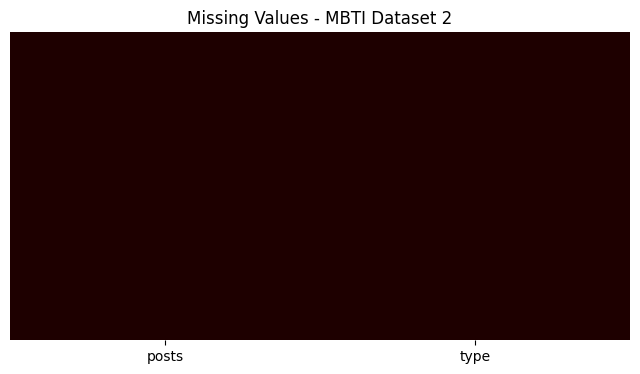

In [ ]:
plt.figure(figsize=(8,4))

sns.heatmap(mbti500.isnull(),
            cbar=False,
            yticklabels=False,
            cmap="pink")

plt.title("Missing Values - MBTI Dataset 2")

plt.show()

### Observation

The missing value analysis indicates that both the MBTI Personality Dataset and the MBTI-500 Dataset contain no missing values in either the `posts` or `type` columns.

### Conclusion

Since no missing values are present, no imputation or record removal is required. Therefore, all available samples can be retained for subsequent preprocessing and model development, ensuring maximum utilization of the datasets.

# 6. Duplicate Analysis

## Objective

The objective of this section is to identify duplicate records within both datasets. Duplicate analysis is an important step in data quality assessment, as duplicate entries can introduce bias during model training and affect the overall performance of machine learning models.

This section investigates:
- Duplicate rows
- Duplicate textual posts
- Duplicate MBTI personality labels (distribution)
- Percentage of duplicate records

The findings from this analysis will help determine whether duplicate records should be retained or removed during the preprocessing stage.

In [ ]:
# ==============================================================
# 6. DUPLICATE ANALYSIS
# ==============================================================

def duplicate_analysis(df, dataset_name):

    print("="*80)
    print(dataset_name)
    print("="*80)

    total_rows = len(df)

    duplicate_rows = df.duplicated().sum()

    duplicate_posts = df["posts"].duplicated().sum()

    duplicate_percentage = (duplicate_rows / total_rows) * 100

    print(f"Total Rows                : {total_rows}")
    print(f"Duplicate Rows           : {duplicate_rows}")
    print(f"Duplicate Posts          : {duplicate_posts}")
    print(f"Duplicate Percentage     : {duplicate_percentage:.2f}%")

In [ ]:
duplicate_analysis(mbti1,"MBTI Dataset 1")

MBTI Dataset 1
Total Rows                : 8675
Duplicate Rows           : 0
Duplicate Posts          : 0
Duplicate Percentage     : 0.00%


In [ ]:
duplicate_analysis(mbti500,"MBTI Dataset 2")

MBTI Dataset 2
Total Rows                : 106067
Duplicate Rows           : 0
Duplicate Posts          : 0
Duplicate Percentage     : 0.00%


In [ ]:
print("MBTI Dataset 1 Personality Distribution")

display(
    mbti1["type"]
    .value_counts()
    .to_frame("Count")
)

MBTI Dataset 1 Personality Distribution


,Count
type,
INFP,1832
INFJ,1470
INTP,1304
INTJ,1091
ENTP,685
ENFP,675
ISTP,337
ISFP,271
ENTJ,231


In [ ]:
print("MBTI Dataset 2 Personality Distribution")

display(
    mbti500["type"]
    .value_counts()
    .to_frame("Count")
)

MBTI Dataset 2 Personality Distribution


,Count
type,
INTP,24961
INTJ,22427
INFJ,14963
INFP,12134
ENTP,11725
ENFP,6167
ISTP,3424
ENTJ,2955
ESTP,1986


In [ ]:
comparison = pd.DataFrame({

    "Dataset":[
        "MBTI Dataset 1",
        "MBTI Dataset 2"
    ],

    "Total Rows":[
        len(mbti1),
        len(mbti500)
    ],

    "Duplicate Rows":[
        mbti1.duplicated().sum(),
        mbti500.duplicated().sum()
    ],

    "Duplicate Posts":[
        mbti1["posts"].duplicated().sum(),
        mbti500["posts"].duplicated().sum()
    ]

})

comparison

,Dataset,Total Rows,Duplicate Rows,Duplicate Posts
0,MBTI Dataset 1,8675,0,0
1,MBTI Dataset 2,106067,0,0


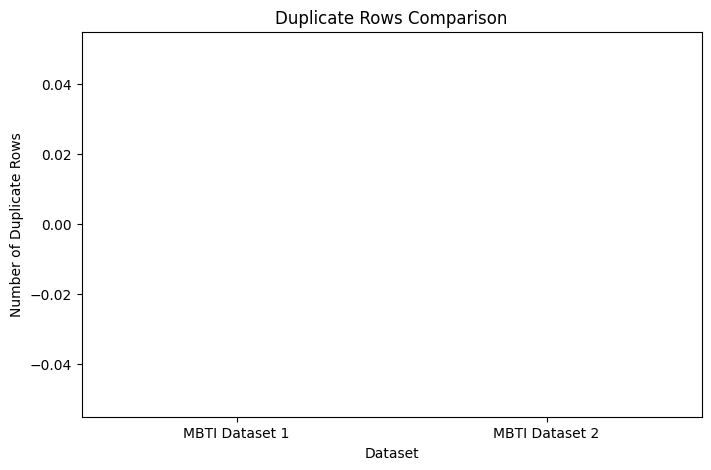

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="Duplicate Rows"
)

plt.title("Duplicate Rows Comparison")

plt.xlabel("Dataset")

plt.ylabel("Number of Duplicate Rows")

plt.show()

## Observation

The duplicate analysis provides an overview of repeated records within each dataset. Duplicate textual posts and duplicate rows are identified to understand the quality and uniqueness of the available data. The MBTI personality labels are also examined to understand their distribution across both datasets.

## Conclusion

The findings from this analysis will guide the preprocessing stage by determining whether duplicate records should be removed or retained. Removing unnecessary duplicate records can improve data quality and reduce potential bias during model training while preserving the overall integrity of the datasets.

# 7. Text Quality Assessment

## Objective

The objective of this section is to assess the quality and characteristics of the textual data before preprocessing. This analysis helps identify potential issues such as extremely short or long posts, URLs, HTML tags, repeated delimiters, emojis, excessive punctuation, and other textual artifacts that may influence Natural Language Processing tasks.

Understanding these characteristics enables the design of an effective preprocessing pipeline while ensuring that valuable linguistic information is preserved.

In [ ]:
###############################################################
# TEXT QUALITY ASSESSMENT
###############################################################

def text_quality(df, dataset_name):

    print("="*80)
    print(dataset_name)
    print("="*80)

    posts = df['posts'].astype(str)

    print(f"Total Posts                 : {len(posts)}")

    print(f"Average Characters          : {posts.str.len().mean():.2f}")

    print(f"Minimum Characters          : {posts.str.len().min()}")

    print(f"Maximum Characters          : {posts.str.len().max()}")

    print(f"Average Words               : {posts.str.split().apply(len).mean():.2f}")

    print(f"Minimum Words               : {posts.str.split().apply(len).min()}")

    print(f"Maximum Words               : {posts.str.split().apply(len).max()}")


In [ ]:
text_quality(mbti1,"MBTI Dataset 1")

MBTI Dataset 1
Total Posts                 : 8675
Average Characters          : 7234.99
Minimum Characters          : 57
Maximum Characters          : 10090
Average Words               : 1226.24
Minimum Words               : 4
Maximum Words               : 1881


In [ ]:
text_quality(mbti500,"MBTI Dataset 2")

MBTI Dataset 2
Total Posts                 : 106067
Average Characters          : 3255.11
Minimum Characters          : 2024
Maximum Characters          : 13180
Average Words               : 500.02
Minimum Words               : 479
Maximum Words               : 527


In [ ]:
def count_urls(df):

    return df["posts"].str.contains(r"http|www",regex=True).sum()

print("URLs in Dataset 1 :",count_urls(mbti1))

print("URLs in Dataset 2 :",count_urls(mbti500))

URLs in Dataset 1 : 5677
URLs in Dataset 2 : 1788


In [ ]:
def count_html(df):

    return df["posts"].str.contains(r"<.*?>",regex=True).sum()

print("HTML Tags in Dataset 1 :",count_html(mbti1))

print("HTML Tags in Dataset 2 :",count_html(mbti500))

HTML Tags in Dataset 1 : 363
HTML Tags in Dataset 2 : 0


In [ ]:
def count_delimiter(df):

    return df["posts"].str.contains(r"\|\|\|",regex=True).sum()

print("Delimiter ||| in Dataset 1 :",count_delimiter(mbti1))

print("Delimiter ||| in Dataset 2 :",count_delimiter(mbti500))

Delimiter ||| in Dataset 1 : 8674
Delimiter ||| in Dataset 2 : 0


In [ ]:
def empty_posts(df):

    return (df["posts"].str.strip()=="").sum()

print("Empty Posts Dataset 1 :",empty_posts(mbti1))

print("Empty Posts Dataset 2 :",empty_posts(mbti500))

Empty Posts Dataset 1 : 0
Empty Posts Dataset 2 : 0


In [ ]:
emoji_pattern = re.compile(
"["
"\U0001F600-\U0001F64F"
"\U0001F300-\U0001F5FF"
"\U0001F680-\U0001F6FF"
"\U0001F1E0-\U0001F1FF"
"]+", flags=re.UNICODE)

def emoji_count(df):

    return df["posts"].apply(lambda x: len(emoji_pattern.findall(str(x)))).sum()

print("Emoji Count Dataset 1 :",emoji_count(mbti1))

print("Emoji Count Dataset 2 :",emoji_count(mbti500))

Emoji Count Dataset 1 : 167
Emoji Count Dataset 2 : 0


In [ ]:
special_pattern = r"[^A-Za-z0-9\s]"

def special_characters(df):

    return df["posts"].str.count(special_pattern).sum()

print("Special Characters Dataset 1 :",special_characters(mbti1))

print("Special Characters Dataset 2 :",special_characters(mbti500))

## Observation

The text quality assessment provides valuable insights into the structure and cleanliness of the textual data. Characteristics such as post length, word count, URLs, HTML tags, delimiters, emojis, and special characters are examined to identify preprocessing requirements.

## Conclusion

The results obtained from this analysis will guide the design of the preprocessing pipeline. Appropriate cleaning techniques will be applied only where necessary to preserve meaningful linguistic information while removing unwanted textual noise.

# 9. Raw Text Inspection

## Objective

Before designing the preprocessing pipeline, it is important to manually inspect the raw textual data. This helps identify the structure of the posts, the presence of delimiters, URLs, HTML tags, emojis, punctuation, and other textual artifacts.

Manual inspection ensures that preprocessing decisions are based on the actual characteristics of the datasets rather than assumptions.

In [ ]:
###############################################################
# DISPLAY RANDOM POSTS FROM BOTH DATASETS
###############################################################

# Display three random posts from Dataset 1

print("="*100)
print("MBTI DATASET 1 - RANDOM POSTS")
print("="*100)

for i, post in enumerate(mbti1["posts"].sample(3, random_state=42),1):

    print(f"\n\nPOST {i}\n")

    print(post)

    print("\n"+"-"*120)

In [ ]:
###############################################################
# DISPLAY RANDOM POSTS FROM DATASET 2
###############################################################

print("="*100)
print("MBTI DATASET 2 - RANDOM POSTS")
print("="*100)

for i, post in enumerate(mbti500["posts"].sample(3, random_state=42),1):

    print(f"\n\nPOST {i}\n")

    print(post)

    print("\n"+"-"*120)

Manual inspection of the datasets revealed significant differences in preprocessing levels. The MBTI Personality Dataset contains raw social media posts with punctuation, delimiters, URLs, and original formatting, whereas the MBTI-500 dataset has already undergone substantial preprocessing, including lowercasing and removal of most punctuation and non-textual elements. Therefore, separate preprocessing strategies will be adopted for each dataset.

# 10. Data Preprocessing

## Objective

The objective of this section is to preprocess the textual data to improve its quality and suitability for Natural Language Processing tasks. Since the two datasets differ in their level of preprocessing, a modular preprocessing pipeline is adopted. Each preprocessing operation is implemented separately to improve transparency, reproducibility, and ease of analysis.

The preprocessing pipeline includes text normalization, URL removal, HTML removal, delimiter handling, emoji removal, punctuation cleaning, whitespace normalization, tokenization, stop-word removal, and lemmatization.

### 10.1 Convert Text to Lowercase

Converting text to lowercase ensures that words differing only in letter casing are treated as identical tokens. This reduces vocabulary size and improves consistency during feature extraction and model training.

In [ ]:
###############################################################
# STEP 1 : CONVERT TEXT TO LOWERCASE
###############################################################

# This function converts all text into lowercase to ensure
# consistency and reduce vocabulary duplication.

def convert_to_lowercase(text):

    return str(text).lower()

In [ ]:
# Apply lowercase conversion

mbti1["posts_lower"] = mbti1["posts"].apply(convert_to_lowercase)

mbti500["posts_lower"] = mbti500["posts"].apply(convert_to_lowercase)

print("Lowercase conversion completed successfully!")

In [ ]:
# Compare before and after

comparison = pd.DataFrame({

    "Original": mbti1["posts"].head(3),

    "Lowercase": mbti1["posts_lower"].head(3)

})

comparison

Original  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8   http://www.youtube.com/watch?v=u8ejam5DP3E  On repeat for most of today.|||May the PerC Experience immerse you.|||The last thing my INFJ friend posted on his facebook before committing suicide the next day. Rest in peace~   http://vimeo.com/22842206|||Hello ENFJ7. Sorry to hear of your distress. It's only natural for a relationship to not be perfection all the time in every moment of existence. Try to figure the hard times as times of growth, as...|||84389  84390  http://wallpaperpassion.com/upload/23700/friendship-boy-and-girl-wallpaper.jpg  http://assets.dornob.com/wp-content/uploads/2010/04/round-home-design.jpg ...|||Welcome and stuff.|||http://playeressence.com/wp-content/uploads/2013/08/RED-red-the-pokemon-master-32560474-450-338.jpg  Game. Set. Match.|||Prozac, wellbrutin, at least thirty minutes of moving your legs (and I don't mean moving them while sitting in your same desk chair), weed in moderation (maybe try edibles as a healthier alternative...|||Basically come up with three items you've determined that each type (or whichever types you want to do) would more than likely use, given each types' cognitive functions and whatnot, when left by...|||All things in moderation.  Sims is 

### 10.2 Remove URLs

Hyperlinks generally do not contribute meaningful semantic information for personality prediction. Therefore, URLs are removed to reduce textual noise while preserving the surrounding linguistic content.

In [ ]:
###############################################################
# STEP 2 : REMOVE URLS
###############################################################

# URLs often represent external references rather than the user's
# own language. Removing them helps retain only meaningful text.

def remove_urls(text):

    url_pattern = r'https?://\S+|www\.\S+'

    return re.sub(url_pattern,'',str(text))

In [ ]:
mbti1["posts_no_urls"] = mbti1["posts_lower"].apply(remove_urls)

mbti500["posts_no_urls"] = mbti500["posts_lower"].apply(remove_urls)

print("URLs removed successfully!")

URLs removed successfully!


In [ ]:
comparison = pd.DataFrame({

    "Before": mbti1["posts_lower"].head(3),

    "After": mbti1["posts_no_urls"].head(3)

})

comparison

Before  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'http://www.youtube.com/watch?v=qsxhcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03pma1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7le1g4xm4  sportscenter not top ten plays  https://www.youtube.com/watch?v=ucdfze1etec  pranks|||what has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vxzeywwrdw8   http://www.youtube.com/watch?v=u8ejam5dp3e  on repeat for most of today.|||may the perc experience immerse you.|||the last thing my infj friend posted on his facebook before committing suicide the next day. rest in peace~   http://vimeo.com/22842206|||hello enfj7. sorry to hear of your distress. it's only natural for a relationship to not be perfection all the time in every moment of existence. try to figure the hard times as times of growth, as...|||84389  84390  http://wallpaperpassion.com/upload/23700/friendship-boy-and-girl-wallpaper.jpg  http://assets.dornob.com/wp-content/uploads/2010/04/round-home-design.jpg ...|||welcome and stuff.|||http://playeressence.com/wp-content/uploads/2013/08/red-red-the-pokemon-master-32560474-450-338.jpg  game. set. match.|||prozac, wellbrutin, at least thirty minutes of moving your legs (and i don't mean moving them while sitting in your same desk chair), weed in moderation (maybe try edibles as a healthier alternative...|||basically come up with three items you've determined that each type (or whichever types you want to do) would more than likely use, given each types' cognitive functions and whatnot, when left by...|||all things in moderation.  sims is in

### 10.3 Remove HTML Tags

HTML tags may appear due to web scraping or formatting artifacts. Since they do not represent natural language, they are removed to improve text quality.

In [ ]:
###############################################################
# STEP 3 : REMOVE HTML TAGS
###############################################################

# Remove HTML tags while preserving the surrounding text.

def remove_html(text):

    html_pattern = r'<.*?>'

    return re.sub(html_pattern,'',str(text))

In [ ]:
mbti1["posts_no_html"] = mbti1["posts_no_urls"].apply(remove_html)

mbti500["posts_no_html"] = mbti500["posts_no_urls"].apply(remove_html)

print("HTML tags removed successfully!")

HTML tags removed successfully!


### 10.4 Replace Post Delimiters

The original MBTI dataset stores multiple social media posts within a single record using the `|||` delimiter. Rather than removing these delimiters, they are replaced with whitespace to preserve the continuity of the textual content while eliminating non-linguistic symbols.

In [ ]:
###############################################################
# STEP 4 : HANDLE POST DELIMITERS
###############################################################

# The delimiter "|||" separates multiple posts within a single
# record. It is replaced with a single whitespace instead of
# being removed completely.

def replace_delimiter(text):

    return text.replace("|||"," ")

In [ ]:
mbti1["posts_delimiter_removed"] = mbti1["posts_no_html"].apply(replace_delimiter)

# Dataset 2 does not contain delimiters.
mbti500["posts_delimiter_removed"] = mbti500["posts_no_html"]

print("Post delimiters handled successfully!")

Post delimiters handled successfully!


### 10.5 Expand Contractions

Contractions such as *don't*, *I'm*, and *can't* are expanded into their complete forms (e.g., *do not*, *I am*, *cannot*). Expanding contractions improves textual consistency and helps machine learning models better capture semantic meaning.

In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.7 MB/s eta 0:00:00


In [ ]:
###############################################################
# STEP 5 : EXPAND CONTRACTIONS
###############################################################

import contractions

# Expand contractions into their complete forms
# Example:
# don't -> do not
# I'm -> I am

def expand_contractions(text):

    return contractions.fix(str(text))

In [ ]:
mbti1["posts_expanded"] = mbti1["posts_delimiter_removed"].apply(expand_contractions)

mbti500["posts_expanded"] = mbti500["posts_delimiter_removed"].apply(expand_contractions)

print("Contractions expanded successfully!")

In [ ]:
comparison = pd.DataFrame({

    "Before": mbti1["posts_delimiter_removed"].head(3),

    "After": mbti1["posts_expanded"].head(3)

})

comparison

### 10.6 Remove Emojis

Although emojis may convey emotional context, their occurrence within both datasets is minimal. Therefore, emojis are removed to maintain textual consistency and reduce non-textual noise during preprocessing.

In [ ]:
###############################################################
# STEP 6 : REMOVE EMOJIS
###############################################################

import re

emoji_pattern = re.compile(
"["
"\U0001F600-\U0001F64F"
"\U0001F300-\U0001F5FF"
"\U0001F680-\U0001F6FF"
"\U0001F1E0-\U0001F1FF"
"]+", flags=re.UNICODE)

def remove_emojis(text):

    return emoji_pattern.sub(r'', str(text))

In [ ]:
mbti1["posts_no_emojis"] = mbti1["posts_expanded"].apply(remove_emojis)

mbti500["posts_no_emojis"] = mbti500["posts_expanded"].apply(remove_emojis)

print("Emoji removal completed successfully!")

### 10.7 Remove User Mentions

User mentions are removed because they represent references to specific users rather than meaningful linguistic information. Eliminating mentions helps reduce dataset-specific noise while preserving the surrounding textual content.

In [ ]:
###############################################################
# STEP 7 : REMOVE USER MENTIONS
###############################################################

def remove_mentions(text):

    return re.sub(r'@\w+', '', str(text))

In [ ]:
mbti1["posts_no_mentions"] = mbti1["posts_no_emojis"].apply(remove_mentions)

mbti500["posts_no_mentions"] = mbti500["posts_no_emojis"].apply(remove_mentions)

print("User mentions removed successfully!")

### 10.8 Remove Hashtags

Hashtags are commonly used to categorize social media posts. During preprocessing, the hash symbol is removed while preserving the associated word, allowing useful semantic information to remain available for analysis.

In [ ]:
###############################################################
# STEP 8 : REMOVE HASHTAGS
###############################################################

def remove_hashtags(text):

    return re.sub(r'#', '', str(text))

In [ ]:
mbti1["posts_no_hashtags"] = mbti1["posts_no_mentions"].apply(remove_hashtags)

mbti500["posts_no_hashtags"] = mbti500["posts_no_mentions"].apply(remove_hashtags)

print("Hashtags processed successfully!")

### 10.9 Remove Numbers

Numbers generally do not contribute meaningful semantic information for personality prediction and may introduce unnecessary variability into the textual data. Therefore, numeric values are removed while preserving the surrounding textual content.

In [ ]:
###############################################################
# STEP 9 : REMOVE NUMBERS
###############################################################

# Remove all numerical values from the text while retaining
# meaningful linguistic information.

def remove_numbers(text):

    return re.sub(r'\d+', '', str(text))

In [ ]:
mbti1["posts_no_numbers"] = mbti1["posts_no_hashtags"].apply(remove_numbers)

mbti500["posts_no_numbers"] = mbti500["posts_no_hashtags"].apply(remove_numbers)

print("Numbers removed successfully!")

### 10.10 Remove Punctuation

Punctuation marks generally do not contribute directly to semantic meaning in text classification tasks. Removing punctuation reduces vocabulary complexity and improves textual consistency for feature extraction.

In [ ]:
###############################################################
# STEP 10 : REMOVE PUNCTUATION
###############################################################

# Replace punctuation with spaces instead of deleting it.
# This prevents adjacent words from merging together
# (e.g., "year-old" becomes "year old" instead of "yearold").

def remove_punctuation(text):

    return re.sub(r"[^\w\s]", " ", str(text))

In [ ]:
mbti1["posts_no_punctuation"] = mbti1["posts_no_numbers"].apply(remove_punctuation)

mbti500["posts_no_punctuation"] = mbti500["posts_no_numbers"].apply(remove_punctuation)

print("Punctuation removed successfully!")

### 10.11 Remove Special Characters

Special characters and non-alphanumeric symbols that do not contribute meaningful linguistic information are removed. This further standardizes the textual data and prepares it for tokenization and feature extraction.

In [ ]:
  ###############################################################
# STEP 11 : REMOVE SPECIAL CHARACTERS
###############################################################

# Remove remaining special characters while preserving
# alphabetic characters and whitespace.

def remove_special_characters(text):

    return re.sub(r'[^a-zA-Z\s]', '', str(text))

In [ ]:
mbti1["posts_no_special"] = mbti1["posts_no_punctuation"].apply(remove_special_characters)

mbti500["posts_no_special"] = mbti500["posts_no_punctuation"].apply(remove_special_characters)

print("Special characters removed successfully!")

### 10.12 Normalize Whitespace

Multiple consecutive spaces and unnecessary whitespace introduced during preprocessing are replaced with a single space. This ensures uniform formatting of the textual data before tokenization.

In [ ]:
###############################################################
# STEP 12 : NORMALIZE WHITESPACE
###############################################################

# Remove extra spaces and normalize whitespace.

def normalize_whitespace(text):

    return re.sub(r'\s+', ' ', str(text)).strip()

In [ ]:
mbti1["posts_normalized"] = mbti1["posts_no_special"].apply(normalize_whitespace)

mbti500["posts_normalized"] = mbti500["posts_no_special"].apply(normalize_whitespace)

print("Whitespace normalized successfully!")

# 11. Tokenization

## Objective

Tokenization is the process of splitting textual data into individual words, known as tokens. It is one of the fundamental steps in Natural Language Processing, allowing machine learning models to analyze and process text at the word level.

Tokenization converts each cleaned social media post into a sequence of words while preserving their order, preparing the data for subsequent preprocessing steps such as stop-word removal and lemmatization.

In [ ]:
###############################################################
# DOWNLOAD REQUIRED NLP RESOURCES
###############################################################

# Download the required NLTK resources for tokenization.

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

In [ ]:
###############################################################
# IMPORT TOKENIZER
###############################################################

# Import the word tokenizer from NLTK.

from nltk.tokenize import word_tokenize

In [ ]:
###############################################################
# STEP 13 : TOKENIZATION
###############################################################

# This function converts each cleaned post into
# a list of individual words (tokens).

def tokenize_text(text):

    return word_tokenize(str(text))

In [ ]:
mbti1["posts_tokens"] = mbti1["posts_normalized"].apply(tokenize_text)

mbti500["posts_tokens"] = mbti500["posts_normalized"].apply(tokenize_text)

print("Tokenization completed successfully!")

In [ ]:
comparison = pd.DataFrame({

    "Normalized Text": mbti1["posts_normalized"].head(3),

    "Tokens": mbti1["posts_tokens"].head(3)

})

comparison

In [ ]:
###############################################################
# TOKEN COUNT ANALYSIS
###############################################################

# Count the total number of tokens in each post.

mbti1["token_count"] = mbti1["posts_tokens"].apply(len)

mbti500["token_count"] = mbti500["posts_tokens"].apply(len)

print("Token counts calculated successfully!")

In [ ]:
###############################################################
# TOKEN STATISTICS
###############################################################

def token_statistics(df, dataset_name):

    print("="*70)
    print(dataset_name)
    print("="*70)

    print(f"Average Tokens : {df['token_count'].mean():.2f}")

    print(f"Minimum Tokens : {df['token_count'].min()}")

    print(f"Maximum Tokens : {df['token_count'].max()}")

In [ ]:
token_statistics(mbti1,"MBTI Dataset 1")

In [ ]:
token_statistics(mbti500,"MBTI Dataset 2")

In [ ]:
###############################################################
# TOKEN DISTRIBUTION
###############################################################

plt.figure(figsize=(10,6))

sns.histplot(
    mbti1["token_count"],
    bins=50,
    kde=True
)

plt.title("Token Count Distribution - MBTI Dataset 1")

plt.xlabel("Number of Tokens")

plt.ylabel("Frequency")

plt.show()

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    mbti500["token_count"],
    bins=50,
    kde=True
)

plt.title("Token Count Distribution - MBTI Dataset 2")

plt.xlabel("Number of Tokens")

plt.ylabel("Frequency")

plt.show()

## Observation

The tokenization process successfully converted each cleaned post into a sequence of individual words. This representation allows the textual data to be processed efficiently during subsequent Natural Language Processing tasks.

The token statistics indicate the variability in post lengths across both datasets and provide useful insights into the complexity of the textual data.

## Conclusion

Tokenization prepares the datasets for advanced preprocessing techniques such as stop-word removal and lemmatization. The generated tokens will form the basis for feature extraction and machine learning model development.

# 12. Stop-word Removal

## Objective

Stop words are commonly occurring words such as *the*, *is*, *and*, and *of* that generally contribute little semantic value in text classification tasks. Removing these words helps reduce vocabulary size and allows machine learning models to focus on more informative linguistic features.

However, personal pronouns such as *I*, *me*, *my*, *we*, *our*, *you*, and *your* are intentionally retained because previous research suggests that pronoun usage can provide useful insights into personality and online communication behaviour.

In [ ]:
###############################################################
# DOWNLOAD STOPWORDS
###############################################################

import nltk

nltk.download("stopwords")

In [ ]:
###############################################################
# IMPORT STOPWORDS
###############################################################

from nltk.corpus import stopwords

In [ ]:
###############################################################
# CREATE CUSTOM STOPWORD LIST
###############################################################

# Load the default English stopword list

stop_words = set(stopwords.words("english"))

# Retain personality-related pronouns

retain_words = {

    "i","me","my","myself",

    "we","our","ours","ourselves",

    "you","your","yours","yourself"

}

# Remove these pronouns from the stopword list

stop_words = stop_words - retain_words

print("Total Stopwords Used :",len(stop_words))

In [ ]:
###############################################################
# REMOVE STOPWORDS
###############################################################

def remove_stopwords(tokens):

    cleaned_tokens = [

        word

        for word in tokens

        if word.lower() not in stop_words

    ]

    return cleaned_tokens

In [ ]:
mbti1["posts_no_stopwords"] = mbti1["posts_tokens"].apply(remove_stopwords)

mbti500["posts_no_stopwords"] = mbti500["posts_tokens"].apply(remove_stopwords)

print("Stopword removal completed successfully!")

In [ ]:
comparison = pd.DataFrame({

    "Before": mbti1["posts_tokens"].head(3),

    "After": mbti1["posts_no_stopwords"].head(3)

})

comparison

# 13. Lemmatization

## Objective

Lemmatization converts words into their base or dictionary form while preserving their contextual meaning. Unlike stemming, lemmatization produces valid words, improving the quality of textual representation and reducing vocabulary redundancy.

For example:

- running → run
- studies → study
- children → child

This process improves feature consistency and enhances the performance of Natural Language Processing models.

In [ ]:
###############################################################
# INSTALL SPACY
###############################################################

!pip install -q spacy

!python -m spacy download en_core_web_sm

In [ ]:
###############################################################
# IMPORT SPACY
###############################################################

import spacy

# Disable components that are not needed for lemmatization
nlp = spacy.load(
    "en_core_web_sm",
    disable=["parser", "ner", "textcat"]
)

In [ ]:
###############################################################
# CONVERT TOKEN LIST TO TEXT
###############################################################

mbti1_text = mbti1["posts_no_stopwords"].apply(
    lambda x: " ".join(x)
).tolist()

mbti500_text = mbti500["posts_no_stopwords"].apply(
    lambda x: " ".join(x)
).tolist()

In [ ]:
################################################################
# SPACY LEMMATIZATION USING NLP.PIPE
###############################################################

def batch_lemmatize(texts, batch_size=100):

    lemmatized = []

    for doc in nlp.pipe(
        texts,
        batch_size=batch_size
    ):

        lemmatized.append(
            [
                token.lemma_
                for token in doc
                if token.lemma_.strip()
            ]
        )

    return lemmatized

In [ ]:
#########################################
# APPLY LEMMATIZATION
###############################################################

mbti1["posts_lemmatized"] = batch_lemmatize(
    mbti1_text,
    batch_size=64
)

mbti500["posts_lemmatized"] = batch_lemmatize(
    mbti500_text,
    batch_size=64
)

print("spaCy Lemmatization Completed Successfully!")

spaCy Lemmatization Completed Successfully!


In [ ]:
comparison = pd.DataFrame({

    "Before": mbti1["posts_no_stopwords"].head(3),

    "After": mbti1["posts_lemmatized"].head(3)

})

comparison

,Before,After
0,"[intj, moments, sportscenter, top, ten, plays, pranks, life, changing, experience, your, life, repeat, today, may, perc, experience, immerse, you, last, thing, my, infj, friend, posted, facebook, committing, suicide, next, day, rest, peace, enfj, sorry, hear, your, distress, natural, relationship, perfection, time, every, moment, existence, try, figure, hard, times, times, growth, welcome, stuff, game, set, match, prozac, wellbrutin, least, thirty, minutes, moving, your, legs, i, mean, moving, sitting, your, desk, chair, weed, moderation, maybe, try, edibles, healthier, alternative, basically, come, three, items, you, determined, type, whichever, types, you, want, would, likely, use, given, types, cognitive, functions, whatnot, left, things, moderation, sims, ...]","[intj, moment, sportscenter, top, ten, play, prank, life, change, experience, your, life, repeat, today, may, perc, experience, immerse, you, last, thing, my, infj, friend, post, facebook, commit, suicide, next, day, rest, peace, enfj, sorry, hear, your, distress, natural, relationship, perfection, time, every, moment, existence, try, figure, hard, time, time, growth, welcome, stuff, game, set, match, prozac, wellbrutin, least, thirty, minute, move, your, leg, I, mean, move, sit, your, desk, chair, weed, moderation, maybe, try, edible, healthy, alternative, basically, come, three, item, you, determine, type, whichever, type, you, want, would, likely, use, give, type, cognitive, function, whatnot, leave, thing, moderation, sim, ...]"
1,"[i, finding, lack, me, posts, alarming, sex, boring, position, often, example, me, my, girlfriend, currently, environment, we, creatively, use, cowgirl, missionary, enough, giving, new, meaning, game, theory, hello, entp, grin, takes, we, converse, flirting, i, acknowledge, presence, return, words, smooth, wordplay, cheeky, grins, lack, balance, hand, eye, coordination, real, iq, test, i, score, internet, iq, tests, funny, i, score, higher, like, former, responses, thread, i, mention, i, believe, iq, test, you, banish, you, know, you, entp, you, vanish, site, year, half, return, find, people, still, commenting, your, posts, liking, your, ideas, thoughts, you, know, you, entp, you, think, things, sometimes, ...]","[I, find, lack, I, post, alarm, sex, boring, position, often, example, I, my, girlfriend, currently, environment, we, creatively, use, cowgirl, missionary, enough, give, new, meaning, game, theory, hello, entp, grin, take, we, converse, flirt, I, acknowledge, presence, return, word, smooth, wordplay, cheeky, grin, lack, balance, hand, eye, coordination, real, iq, test, I, score, internet, iq, test, funny, I, score, higher, like, former, response, thread, I, mention, I, believe, iq, test, you, banish, you, know, you, entp, you, vanish, site, year, half, return, find, people, still, comment, your, post, like, your, idea, thought, you, know, you, entp, you, think, thing, sometimes, ...]"
2,"[good, one, course, i, say, i, know, my, blessing, my, curse, absolutely, positive, you, your, best, friend, could, amazing, couple, count, yes, i, could, madly, love, case, i, reconciled, my, feelings, i, thank, you, link, called, ti, si, loop, stem, current, topic, obsession, deadly, like, you, stuck, your, thoughts, your, mind, wanders, circles, feels, truly, terrible, you, noticed, peculiar, vegetation, you, look, grass, dozens, different, plant, species, imagine, hundreds, years, later, soil, smiths, never, one, ever, i, often, find, myself, spotting, faces, marble, tiles, wood, year, old, sentence, incredibly, accurate, beautiful, description, i, visited, website, last, years, whoever, reads, maybe, ...]","[good, one, course, I, say, I, know, my, blessing, my, curse, absolutely, positive, you, your, good, friend, could, amazing, couple, count, yes, I, could, madly, love, case, I, reconcile, my, feeling, I, thank, you, link, call, ti, si, loop, stem, current, topic, obsession, deadly, like, you, stick, your, thought, yo

# 14. Comparison of Raw and Preprocessed Text

## Objective

This section compares the original raw text with the final preprocessed text to illustrate the cumulative effect of each preprocessing step. This comparison demonstrates how textual noise has been removed while preserving meaningful linguistic information required for personality prediction.

In [ ]:
###############################################
# ORIGINAL VS FINAL TEXT
###############################################################

comparison = pd.DataFrame({

    "Original Text": mbti1["posts"].head(5),

    "Final Preprocessed Text": mbti1["posts_lemmatized"].apply(lambda x: " ".join(x)).head(5)

})

comparison

Original Text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   'http://www.youtube.com/watch?v=qsXHcwe3krw|||http://41.media.tumblr.com/tumblr_lfouy03PMA1qa1rooo1_500.jpg|||enfp and intj moments  https://www.youtube.com/watch?v=iz7lE1g4XM4  sportscenter not top ten plays  https://www.youtube.com/watch?v=uCdfze1etec  pranks|||What has been the most life-changing experience in your life?|||http://www.youtube.com/watch?v=vXZeYwwRDw8   http://www.youtube.com/watch?v=u8ejam5DP3E  On repeat for most of today.|||May the PerC Experience immerse you.|||The last thing my INFJ friend posted on his facebook before committing suicide the next day. Rest in peace~   http://vimeo.com/22842206|||Hello ENFJ7. Sorry to hear of your distress. It's only natural for a relationship to not be perfection all the time in every moment of existence. Try to figure the hard times as times of growth, as...|||84389  84390  http://wallpaperpassion.com/upload/23700/friendship-boy-and-girl-wallpaper.jpg  http://assets.dornob.com/wp-content/uploads/2010/04/round-home-design.jpg ...|||Welcome and stuff.|||http://playeressence.com/wp-content/uploads/2013/08/RED-red-the-pokemon-master-32560474-450-338.jpg  Game. Set. Match.|||Prozac, wellbrutin, at least thirty minutes of moving your legs (and I don't mean moving them while sitting in your same desk chair), weed in moderation (maybe try edibles as a healthier alternative...|||Basically come up with three items you've determined that each type (or whichever types you want to do) would more than likely use, given each types' cognitive functions and whatnot, when left by...|||All things in moderation.  Sim

## Observation

The preprocessing pipeline successfully removed textual noise including URLs, HTML tags, emojis, special characters, and unnecessary formatting while preserving meaningful linguistic content.

The resulting text is more standardized, making it suitable for feature extraction and subsequent machine learning tasks.

## Conclusion

The final preprocessed datasets provide high-quality textual representations that can now be used for exploratory data analysis, traditional machine learning models, and transformer-based approaches.

# 15. Final Dataset Summary

## Objective

This section provides a summary of the final preprocessed datasets after completing all Natural Language Processing preprocessing steps. The processed datasets are now standardized and ready for exploratory data analysis, feature engineering, model development, and evaluation.

In [ ]:
###############################################################
# FINAL DATASET PREVIEW
###############################################################

print("="*80)
print("MBTI DATASET 1")
print("="*80)

display(
    mbti1[["type","posts_lemmatized"]].head()
)

print("\n")

print("="*80)
print("MBTI DATASET 2")
print("="*80)

display(
    mbti500[["type","posts_lemmatized"]].head())

MBTI DATASET 1


,type,posts_lemmatized
0,INFJ,"[intj, moment, sportscenter, top, ten, play, prank, life, change, experience, your, life, repeat, today, may, perc, experience, immerse, you, last, thing, my, infj, friend, post, facebook, commit, suicide, next, day, rest, peace, enfj, sorry, hear, your, distress, natural, relationship, perfection, time, every, moment, existence, try, figure, hard, time, time, growth, welcome, stuff, game, set, match, prozac, wellbrutin, least, thirty, minute, move, your, leg, I, mean, move, sit, your, desk, chair, weed, moderation, maybe, try, edible, healthy, alternative, basically, come, three, item, you, determine, type, whichever, type, you, want, would, likely, use, give, type, cognitive, function, whatnot, leave, thing, moderation, sim, ...]"
1,ENTP,"[I, find, lack, I, post, alarm, sex, boring, position, often, example, I, my, girlfriend, currently, environment, we, creatively, use, cowgirl, missionary, enough, give, new, meaning, game, theory, hello, entp, grin, take, we, converse, flirt, I, acknowledge, presence, return, word, smooth, wordplay, cheeky, grin, lack, balance, hand, eye, coordination, real, iq, test, I, score, internet, iq, test, funny, I, score, higher, like, former, response, thread, I, mention, I, believe, iq, test, you, banish, you, know, you, entp, you, vanish, site, year, half, return, find, people, still, comment, your, post, like, your, idea, thought, you, know, you, entp, you, think, thing, sometimes, ...]"
2,INTP,"[good, one, course, I, say, I, know, my, blessing, my, curse, absolutely, positive, you, your, good, friend, could, amazing, couple, count, yes, I, could, madly, love, case, I, reconcile, my, feeling, I, thank, you, link, call, ti, si, loop, stem, current, topic, obsession, deadly, like, you, stick, your, thought, your, mind, wander, circle, feel, truly, terrible, you, notice, peculiar, vegetation, you, look, grass, dozen, different, plant, specie, imagine, hundred, year, later, soil, smith, never, one, ever, I, often, find, myself, spot, face, marble, tile, wood, year, old, sentence, incredibly, accurate, beautiful, description, I, visit, website, last, year, whoever, read, maybe, ...]"
3,INTJ,"[dear, intp, I, enjoy, our, conversation, day, esoteric, gabbing, nature, universe, idea, every, rule, social, code, arbitrary, construct, create, dear, entj, sub, long, time, see, sincerely, alpha, none, type, hurt, deep, existential, way, I, want, part, probably, slide, scale, depend, individual, preference, like, everything, humanity, draco, malfoy, also, I, would, say, either, I, either, though, stack, I, somewhat, arbitrary, distinction, make, I, believe, core, indicate, primary, motivation, hand, every, action, therefore, I, particularly, introvert, extraverte, personally, say, I, would, say, I, somewhat, unphase, either, social, interaction, alone, I, would, say, I, crave, anything, dear, type, infp, your, absolute, admiration, I, ...]"
4,ENTJ,"[you, fire, another, silly, misconception, approach, logically, go, key, unlocking, whatever, you, think, you, entitle, nobody, want, approach, bs, guy, really, want, go, super, dup, long, ass, vacation, c, mon, guy, boss, listen, get, even, approach, logically, everything, never, mind, go, permanent, vacation, two, month, I, would, crazy, idea, you, really, good, employee, may, cooking, want, reliable, asset, go, long, entj, employer, lol, like, our, view, unsolicite, victim, sometimes, I, really, like, impoverished, rap, music, probably, would, lost, stonewall, insignificant, idiot, semantic, impact, anything, one, thing, stone, wall, critical, shit, I, would, take, project, give, something, late, court, deposition, skit, ...]"




MBTI DATASET 2


,type,posts_lemmatized
0,INTJ,"[know, intj, tool, use, interaction, people, excuse, antisocial, truly, enlighten, mastermind, know, would, count, pet, peeze, something, time, matter, people, either, whether, group, people, mall, never, see, good, friend, sit, outside, conversation, jsut, listen, want, interject, sit, formulate, say, wait, inject, argument, think, find, fascinate, sit, watch, people, talk, people, fascinate, sit, class, watch, different, people, find, intrigue, dad, intj, you, stand, look, like, line, safeway, watch, people, home, talk, people, like, think, military, job, people, voluntarily, go, job, important, show, deference, endanger, live, glorify, way, civilian, think, pretty, ignorant, general, think, military, necessary, defense, mechanism, political, tactic, feel, like, ...]"
1,INTJ,"[rap, music, ehh, opp, yeah, know, valid, well, know, fact, people, like, socialize, party, even, personality, let, alone, personality, type, reason, remain, mystery, likely, function, stack, see, party, goer, barely, function, function, stack, well, fact, even, get, two, together, nigh, impossible, lead, entire, personality, consist, shadow, function, though, theorize, widely, dismiss, though, may, help, explain, inherent, love, night, life, like, something, stop, apply, eliminate, genuine, character, flaw, quickly, notice, rationalisation, vote, trump, basically, hillary, attractive, candidate, lacklustre, corrupt, beg, question, president, racist, sexist, bad, really, care, le, either, way, judge, quality, popularity, stop, pussy, something, swing, go, bar, pick, random, ...]"
2,INTJ,"[preferably, p, hd, low, except, wew, lad, video, p, mind, good, reason, agree, statement, relationship, become, difficu, maintain, people, involve, different, stag, life, constantly, feel, though, feign, certain, emotion, counteract, natural, appearance, aloofness, excite, someone, engagement, welcome, someone, bring, child, office, internally, really, care, either, thing, order, mesh, generally, e, office, one, strategically, fake, make, act, like, thing, matter, family, use, phase, anymore, naturally, open, almost, difficu, fake, around, one, occasion, year, feel, obligate, feign, emotion, actually, comfortable, around, people, overcome, social, anxiety, fake, emotion, appear, le, detach, completely, different, former, take, time, persistent, effort, latter, patch, gauze, cover, wind, ...]"
3,INTJ,"[drink, like, wish, could, drink, red, wine, give, headache, almost, instantaneously, apparently, people, really, sensitive, byproduct, red, wine, esfp, bite, place, blissful, go, flow, state, change, anything, brother, middle, right, thread, really, help, realize, need, change, honestly, assume, op, know, try, make, funny, post, even, giggle, also, wonder, would, downvote, guy, people, get, mad, get, joke, really, know, suppose, one, minority, social, recluse, would, quite, sad, buddhist, strong, humanist, lean, particularly, see, much, geographical, difference, two, hate, sleep, waste, time, hard, stop, think, enough, brain, turn, jesus, christ, close, home, every, weeknight, conversation, wife, believe, man, attract, status, way, believe, ...]"
4,INTJ,"[space, program, ah, bad, deal, meing, freelance, max, seem, get, still, upgrade, haul, connie, hate, fut, want, build, manage, team, play, career, restrict, chemistry, contract, want, play, online, play, h, h, season, level, play, field, fut, bad, world, bass, player, run, kind, issue, long, time, realize, force, bassist, need, flashy, usually, get, way, range, make, distinguish, note, pretty, difficu, average, listener, take, away, overall, effect, band, effective, addition, ever, make, song, rhythmic, instead, think, play, think, win, play, example, ringo, starr, space, fill, hang, back, get, fill, feel, enough, time, inhabit, center, groove, feel, want, say, time, right, also, practice, ...]"


In [ ]:
###############################################################
# FINAL TOKEN STATISTICS
###############################################################

summary = pd.DataFrame({

    "Dataset":[

        "MBTI Dataset 1",

        "MBTI Dataset 2"

    ],

    "Average Tokens":[

        round(
            mbti1["posts_lemmatized"].apply(len).mean(),2
        ),

        round(
            mbti500["posts_lemmatized"].apply(len).mean(),2
        )

    ],

    "Minimum Tokens":[

        mbti1["posts_lemmatized"].apply(len).min(),

        mbti500["posts_lemmatized"].apply(len).min()

    ],

    "Maximum Tokens":[

        mbti1["posts_lemmatized"].apply(len).max(),

        mbti500["posts_lemmatized"].apply(len).max()

    ]

})

summary

,Dataset,Average Tokens,Minimum Tokens,Maximum Tokens
0,MBTI Dataset 1,729.61,0,1101
1,MBTI Dataset 2,499.34,387,528


In [ ]:
###############################################################
# CHECK EMPTY POSTS AFTER PREPROCESSING
###############################################################

print("Empty Posts After Preprocessing")

print("-"*40)

print(

    "Dataset 1 :",

    (mbti1["posts_lemmatized"].apply(len)==0).sum()

)

print(

    "Dataset 2 :",

    (mbti500["posts_lemmatized"].apply(len)==0).sum()
)

Empty Posts After Preprocessing
----------------------------------------
Dataset 1 : 1
Dataset 2 : 0


# 16. Save Final Preprocessed Datasets

## Objective

The final preprocessed datasets are converted back into continuous text and saved for future stages of the dissertation. These datasets will be used for exploratory data analysis, feature extraction, traditional machine learning models, transformer-based models, and performance evaluation.

In [ ]:
###############################################################
# CONVERT TOKENS BACK TO TEXT
###############################################################

mbti1["clean_text"] = mbti1["posts_lemmatized"].apply(

    lambda tokens: " ".join(tokens)

)

mbti500["clean_text"] = mbti500["posts_lemmatized"].apply(

    lambda tokens: " ".join(tokens)

)

In [ ]:
###############################################################
# CREATE FINAL DATASETS
###############################################################

mbti1_final = mbti1[["type","clean_text"]]

mbti500_final = mbti500[["type","clean_text"]]

print("Final datasets created successfully!")

Final datasets created successfully!


In [ ]:
###############################################################
# SAVE DATASETS
###############################################################

mbti1_final.to_csv(

    "/content/drive/MyDrive/Dissertation/Datasets/mbti1_preprocessed.csv",

    index=False

)

mbti500_final.to_csv(

    "/content/drive/MyDrive/Dissertation/Datasets/mbti500_preprocessed.csv",

    index=False

)

print("Preprocessed datasets saved successfully!")

In [ ]:
###############################################################
# VERIFY SAVED DATASETS
###############################################################

print("="*80)

print("MBTI DATASET 1")

print("="*80)

display(mbti1_final.head())

print("\n")

print("="*80)

print("MBTI DATASET 2")

print("="*80)

display(mbti500_final.head())

MBTI DATASET 1


,type,clean_text
0,INFJ,intj moment sportscenter top ten play prank life change experience your life repeat today may perc experience immerse you last thing my infj friend post facebook commit suicide next day rest peace enfj sorry hear your distress natural relationship perfection time every moment existence try figure hard time time growth welcome stuff game set match prozac wellbrutin least thirty minute move your leg I mean move sit your desk chair weed moderation maybe try edible healthy alternative basically come three item you determine type whichever type you want would likely use give type cognitive function whatnot leave thing moderation sim indeed video game good one note good one somewhat subjective I completely promote death give sim dear enfp your favorite video game grow your current favorite video game cool appear late sad someone everyone wait I think confidence good thing I cherish time solitude b c I revel within my inner world whereas time I would workin enjoy I time you worry people always around yo entp lady you complimentary personality well hey your main social outlet xbox live conversation even you verbally fatigue quickly I really dig part thread require I get high backyard roast eat marshmellow backyard converse something intellectual follow massage kiss many b sentence could you think b ban watch movie corner dunce ban health class clearly teach you nothing peer pressure ban whole host reason two baby deer leave right munching beetle middle use blood two caveman diary today late happening designate cave diary wall I see pokemon world infj society everyone become optimist artist artist draw idea count form something your like signature welcome robot rank person down my self esteem cuz I avid signature artist like proud ban taking room my bed ya get learn share roach much thunder grumble kind storm yep ahh old high school music I hear age fail public speaking class year ago I sort learn I could well I position big part my failure overload myself I like person mentality confirm intj way denver area start new life myself
1,ENTP,I find lack I post alarm sex boring position often example I my girlfriend currently environment we creatively use cowgirl missionary enough give new meaning game theory hello entp grin take we converse flirt I acknowledge presence return word smooth wordplay cheeky grin lack balance hand eye coordination real iq test I score internet iq test funny I score higher like former response thread I mention I believe iq test you banish you know you entp you vanish site year half return find people still comment your post like your idea thought you know you entp you think thing sometimes I go old sherlock holme quote perhaps man special knowledge special power like my rather encourage seek complex cheshirewolf tumblr com I post really I never think e I j p real function I judge myself I use I use ne ti my dominate fe emotion rarely si I also use ni due I strength you know though ingenious say I really want try see happen I play first person shooter back we drive around I want see look rock paper one good make I lol you guy lucky I really high tumblr system you hear new first person shooter game I rock hell soundtrack my auto sound equipment shake heaven we manage put couple ps way connect thing ne ne dominate aware environment se dominate example shawn spencer patrick jane entps well charlie I first admit I get jealous like you I chalk my w heart mix my dominate w like notice like know I upload clip mic away my mouth you hear anything ninja assassin style splatter tik tok really great song long you mental block singer I love beat make I bounce drop io vswck mic really close my mouth smokin ace assassins ball play background sociable extrovert I extrovert I sociable sherlock movie entp normally play extj book estj I say movie look good except call sherlock holmes I never fear kiss guy I kiss animal nothing vanish personal taste I like guy I kiss know I one sound pretty much like my area I



MBTI DATASET 2


,type,clean_text
0,INTJ,know intj tool use interaction people excuse antisocial truly enlighten mastermind know would count pet peeze something time matter people either whether group people mall never see good friend sit outside conversation jsut listen want interject sit formulate say wait inject argument think find fascinate sit watch people talk people fascinate sit class watch different people find intrigue dad intj you stand look like line safeway watch people home talk people like think military job people voluntarily go job important show deference endanger live glorify way civilian think pretty ignorant general think military necessary defense mechanism political tactic feel like you specifically invest much money could put money education whatnot though personally sound budget aernative really comment one way base two politician eye year ago come name somewhat important kind role model nowadays pick keep score individual level mean little vary accord number condition day may score high other low sweat really good cast physiotherapist like fiberglas cast break arm whatever sometimes want take picture beast put someone arm sadly people blind brilliance need tell directly wave arm frantically totally beyond oblivious get good eye contact help lot start find like attention get opposite sex notice however gay man tend little aggressive always walk away flat like alcohol bad start generally keep go pas run money even mention fact crave cocaine drink political power mainly desire form power okay status still never study day life never learn study feel like real whatever reason college prepare recieve people like depend career introductory course help start rid bike write essay etc choose career least stimulate mind expand perspective reality without college like kiss sound ear yup roll end quite strange confession time mind wish people le judgemental self perceive flaw run situation person confess something expect judge one way another freak realize judge gasp human interpret acknowledgement sign terrible person agree bad impulse ditch safe place quickly become somewhere dump emotional trash gui free interest play role mind noise midnight still go make really cranky lol already know autistic even know asd associate intj people mind two even remotely similar card conspiracy hallmark post office long enough people whether individual people government conglomerate corporation understand biodiversity something need fund even though make money instead insurance policy fine aka negative external form cost need separate positive surplus cost much thing like seed bank visualize cost percent farm benefit cost yet need fund separately individual farmer individual farmer corporation think well someone else people free rider problem seed bank never get set stuff like government capitalism may provide innovation government set regulation prevent negative consequence unintentional externality seed bank get set half thousand different solution perhaps general tax commerce usage fee similar california recycle fee electronic form donation pledge system regardless need get seed bank get expert truely know enough need biodiversity seed farm whether enough seed farm different location properly fund amp bsp say expert know enough due single college class involve economic say economic class involve lot history use case study green revolution
1,INTJ,rap music ehh opp yeah know valid well know fact people like socialize party even personality let alone personality type reason remain mystery likely function stack see party goer barely function function stack well fact even get two together nigh impossible lead entire personality consist shadow function though theorize widely dismiss though may help explain inherent love night life like something stop apply eliminate genuine character flaw quickly notice rationalisation vote trump basically hillary attractive candidate lacklustre corrupt beg question president racist sexist bad really care le either

# 17. MBTI Personality Distribution

## Objective

This section analyzes the distribution of the sixteen MBTI personality types in both datasets.

Understanding the class distribution is essential before model development because class imbalance may influence the performance of machine learning algorithms.

In [ ]:
###############################################################
# CLASS DISTRIBUTION
###############################################################

print("="*70)
print("MBTI DATASET 1")
print("="*70)

display(
    mbti1["type"]
    .value_counts()
    .sort_index()
)

print()

print("="*70)
print("MBTI DATASET 2")
print("="*70)

display(
    mbti500["type"]
    .value_counts()
    .sort_index()
)

MBTI DATASET 1


,count
type,
ENFJ,190
ENFP,675
ENTJ,231
ENTP,685
ESFJ,42
ESFP,48
ESTJ,39
ESTP,89
INFJ,1470



MBTI DATASET 2


,count
type,
ENFJ,1534
ENFP,6167
ENTJ,2955
ENTP,11725
ESFJ,181
ESFP,360
ESTJ,482
ESTP,1986
INFJ,14963


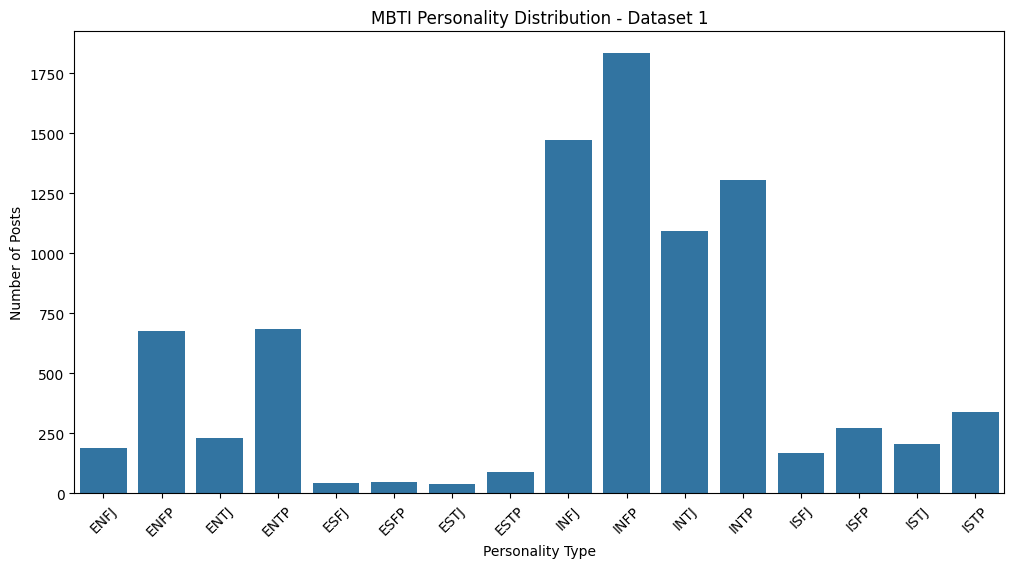

In [ ]:
###############################################################
# BAR CHART - DATASET 1
###############################################################

plt.figure(figsize=(12,6))

sns.countplot(
    data=mbti1,
    x="type",
    order=sorted(mbti1["type"].unique())
)

plt.title("MBTI Personality Distribution - Dataset 1")

plt.xlabel("Personality Type")

plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

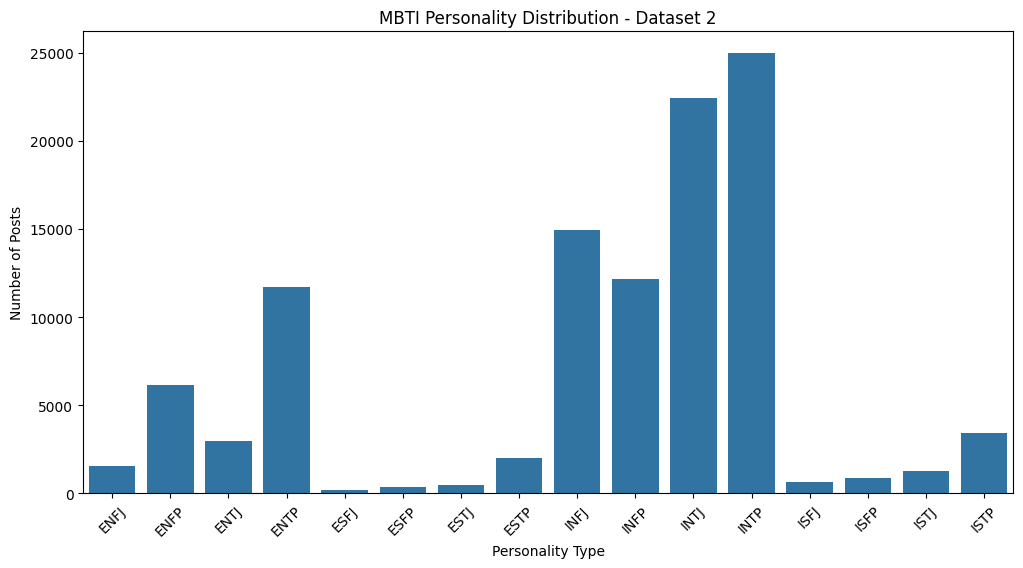

In [ ]:
###############################################################
# BAR CHART - DATASET 2
###############################################################

plt.figure(figsize=(12,6))

sns.countplot(
    data=mbti500,
    x="type",
    order=sorted(mbti500["type"].unique())
)

plt.title("MBTI Personality Distribution - Dataset 2")

plt.xlabel("Personality Type")

plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

In [ ]:
###############################################################
# PERCENTAGE DISTRIBUTION
###############################################################

distribution = pd.DataFrame({

    "Dataset 1 (%)":

    round(

        mbti1["type"]

        .value_counts(normalize=True)

        .sort_index()*100,

        2

    ),

    "Dataset 2 (%)":

    round(

        mbti500["type"]

        .value_counts(normalize=True)

        .sort_index()*100,

        2

    )

})

distribution